# Pipeline replication with NaMaster cross-check

`pipeline_replication.ipynb` already established that running heracles outside the LE3
pipeline reproduces the pipeline's own output almost exactly. This notebook builds on
that result: instead of recomputing the full heracles measurement again, it treats the
pipeline's own binned `SHE-SHE` spectra as ground truth, and checks that an independent
NaMaster measurement - built directly from the real TR1 shear catalogue and coverage
mask, using the same method as `heracles_NaMaster_Camb_example.ipynb` - also matches
the pipeline output.

## params and input files

In [4]:
nside = 1024
lmin = 10
lmax = 1500
nlbins = 30

In [5]:
import fitsio
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import heracles
import pymaster as nmt

DATA_DIR = "pipeline_input"
OUT_DIR = "pipeline_output"

### coverage mask

Only used to get `fsky`, the mean of the real-valued effective-coverage map - exactly
what heracles itself uses (`catalog.fsky`, set via `she_cat.visibility = coverage` in
`pipeline_replication.ipynb`). The actual NaMaster mask for each tomographic bin is
that bin's own weight map, built below.

In [18]:
def read_map(path, nside, *, nest=False):
    """
    Read a HEALPix map in "partial" format from *path* and return it at
    resolution *nside*.
    The returned NSIDE cannot be larger than the NSIDE of the stored
    map.
    If *nest* is true, returns the map in NESTED ordering.
    """
    data, header = fitsio.read(path, header=True)
    nside_in = header["NSIDE"]
    fact = (nside_in // nside) ** 2
    if fact == 0:
        raise ValueError(
            f"requested NSIDE={nside} greater than map NSIDE={nside_in}"
        )
    out = np.zeros(12 * nside**2)
    ipix, wht = data["PIXEL"], data["WEIGHT"]
    order = header["ORDERING"]
    if order == "RING":
        ipix = hp.ring2nest(nside, ipix)
    elif order != "NESTED":
        raise ValueError(f"unknown pixel ordering {order} in map")
    ipix = ipix // fact
    if not nest:
        ipix = hp.nest2ring(nside, ipix)
    np.add.at(out, ipix, wht / fact)
    return out


fname = f"{DATA_DIR}/EUC_LE3_VMPZ-ID_HPEFFECTIVECOVERAGE-CONCAT-20251204T094108.787432Z_0.12.fits"
coverage = read_map(fname, nside)
coverage[coverage == hp.UNSEEN] = 0.0

# fsky as used by heracles is the *mean of the (real-valued) visibility*, not the
# mean of a binarised footprint mask - `she_cat.visibility = coverage` in
# pipeline_replication.ipynb, so this is exactly `catalog.fsky` there
fsky = coverage.mean()

### shear catalogue

In [12]:
catalogShe = heracles.FitsCatalog(f"{DATA_DIR}/EUC_LE3_WLCATALOG-CONCAT-20251218T164508.418188Z_00.00.fits")
she_bins = {i: catalogShe[f"TOM_BIN_ID == {i}"] for i in range(1, 7)}

### pipeline's own measured spectra (ground truth)

Read straight from the pipeline output, no heracles recomputation - `pipeline_replication.ipynb`
already confirmed this matches an independent heracles run to high precision.

In [13]:
CLS_FILE = f"{OUT_DIR}/EUC_LE3_PKWL-SPECTRA-BINNED_1708440_20260414T135912.860079Z_26.02.fits"
cls_pipe = heracles.read(CLS_FILE)

# same log-spaced bin edges the pipeline itself uses, confirmed in pipeline_replication.ipynb
ledges = np.logspace(np.log10(lmin), np.log10(lmax), nlbins + 1)

### NaMaster: per-bin shear maps and fields

Per-pixel weighted-mean shear map built directly from the catalogue (NaMaster expects
the true field, not a pre-weighted one). The sign of `SHE_E1_CORRECTED` is flipped to
match the pipeline's own `SHE` field definition (`-SHE_E1_CORRECTED`).

Crucially, the NaMaster "mask" for each bin is that bin's own per-pixel *weight* map
(`WHT`), not a shared binary footprint - this is exactly what heracles itself uses as
the mask for the `SHE` field (`fieldsShe: mask="WHT"` in `pipeline_replication.ipynb`),
normalised the same way heracles normalises its own `WHT` field.

In [19]:
n_pix = hp.nside2npix(nside)


def build_shear_field(cat, fsky):
    sum_w = np.zeros(n_pix)
    sum_w_e1 = np.zeros(n_pix)
    sum_w_e2 = np.zeros(n_pix)
    ngal = 0
    wmean = 0.0
    for page in cat:
        ra, dec, e1, e2, w = page.get(
            "SHE_RA", "SHE_DEC", "SHE_E1_CORRECTED", "SHE_E2_CORRECTED", "SHE_WEIGHT"
        )
        e1 = -e1
        pix = hp.ang2pix(nside, ra, dec, lonlat=True)
        np.add.at(sum_w, pix, w)
        np.add.at(sum_w_e1, pix, w * e1)
        np.add.at(sum_w_e2, pix, w * e2)
        ngal += page.size
        wmean += (w - wmean).sum() / ngal
        del ra, dec, e1, e2, w, pix

    # same normalisation heracles uses for its own "WHT" mask field (fields.py,
    # Weights.__call__): wbar = ngal / (4*pi*fsky) * wmean * mapper.area, with
    # mapper.area = 4*pi / n_pix for an equal-area HEALPix mapper
    wbar = ngal * wmean / (fsky * n_pix)
    wht = sum_w / wbar

    # weighted-mean shear per pixel - NaMaster multiplies this by the mask/weight
    # map internally, reproducing heracles' own (unnormalised) SHE map exactly
    g1 = np.divide(sum_w_e1, sum_w, out=np.zeros(n_pix), where=sum_w > 0)
    g2 = np.divide(sum_w_e2, sum_w, out=np.zeros(n_pix), where=sum_w > 0)
    return g1, g2, wht


# each tomographic bin gets its own weight ("WHT") map as its NaMaster mask, exactly
# matching heracles' own `fieldsShe` definition (`mask="WHT"`) - a shared binary
# footprint mask would not reproduce heracles' mode-coupling normalisation
namaster_fields = {}
namaster_wht = {}
for i in range(1, 7):
    g1, g2, wht = build_shear_field(she_bins[i], fsky)
    namaster_wht[i] = wht
    namaster_fields[i] = nmt.NmtField(wht, [g1, g2], lmax=lmax)

### NaMaster: noise bias per bin

NaMaster's raw coupled Cl includes the full shot-noise contribution, while the pipeline's
measured spectra are shot-noise-debiased by default. Rather than rerunning heracles' own
field transform just to read off its `bias` metadata, we reproduce heracles' exact shear
noise-bias formula (see `heracles/fields.py`, `Shears.__call__`) directly from the
catalogue, using the same mask as the NaMaster fields above.

In [20]:
def shear_noise_bias(cat, fsky):
    ngal = 0
    wmean, w2mean, var = 0.0, 0.0, 0.0
    for page in cat:
        e1, e2, w = page.get("SHE_E1_CORRECTED", "SHE_E2_CORRECTED", "SHE_WEIGHT")
        e1 = -e1
        re, im = w * e1, w * e2
        ngal += page.size
        wmean += (w - wmean).sum() / ngal
        w2mean += (w**2 - w2mean).sum() / ngal
        var += (re**2 + im**2 - var).sum() / ngal
        del e1, e2, w, re, im
    musq = var / w2mean
    deff = w2mean / wmean**2
    dens = ngal / (4 * np.pi * fsky) / deff
    return (1 / 2) * fsky * musq / dens


namaster_noise_bias = {i: shear_noise_bias(she_bins[i], fsky) for i in range(1, 7)}

### NaMaster: coupled Cl for all bin pairs, binned to match the pipeline

In [21]:
namaster_cl = {}
for i in range(1, 7):
    for j in range(i, 7):
        cl_ij = nmt.compute_coupled_cell(namaster_fields[i], namaster_fields[j])
        cl_ee, cl_bb = cl_ij[0], cl_ij[3]
        if i == j:
            # only auto-spectra carry a shot-noise bias to subtract
            cl_ee = cl_ee - namaster_noise_bias[i]
            cl_bb = cl_bb - namaster_noise_bias[i]
        ee_binned = heracles.binned(heracles.Result(cl_ee, axis=-1), ledges)
        bb_binned = heracles.binned(heracles.Result(cl_bb, axis=-1), ledges)
        namaster_cl[i, j] = (np.asarray(ee_binned), np.asarray(bb_binned))

### Compare NaMaster vs pipeline

In [22]:
ell_bp = np.asarray(cls_pipe["SHE", "SHE", 1, 1].ell)

for i, j in [(1, 1), (3, 3), (6, 6), (1, 3)]:
    ee_pipe = np.asarray(cls_pipe["SHE", "SHE", i, j][0, 0])
    ee_nmt, bb_nmt = namaster_cl[i, j]
    print(f"\n--- SHE-SHE ({i},{j}) EE ---")
    print("pipeline :", ee_pipe)
    print("NaMaster :", ee_nmt)
    print("ratio    :", ee_nmt / ee_pipe)


--- SHE-SHE (1,1) EE ---
pipeline : [ 1.98697569e-12  3.24211706e-12  4.19017695e-12  4.34419385e-12
  3.43928747e-12  2.24688941e-12  2.42516130e-12  4.85788171e-12
  6.70121995e-12  4.58396845e-12  1.32105719e-12  7.42447782e-13
  2.23021118e-12 -4.50323900e-13  1.10091792e-12  2.65780113e-12
  8.07272381e-13  1.29951855e-12  1.23044195e-12  7.80837618e-13
  3.71695357e-13  5.37905899e-13 -7.43851304e-14  4.54187563e-13
  4.63864409e-13 -1.46613478e-13  1.79282453e-13  1.87973027e-13
  4.21716362e-13 -9.85849796e-14]
NaMaster : [ 1.98693783e-12  3.24204883e-12  4.19006550e-12  4.34405975e-12
  3.43916454e-12  2.24677491e-12  2.42492111e-12  4.85722481e-12
  6.70009629e-12  4.58302010e-12  1.32072010e-12  7.42186129e-13
  2.22904501e-12 -4.49898982e-13  1.09967125e-12  2.65352845e-12
  8.05513997e-13  1.29564639e-12  1.22503135e-12  7.76355675e-13
  3.68517687e-13  5.31468246e-13 -7.32070116e-14  4.43227657e-13
  4.50109164e-13 -1.40193539e-13  1.69113074e-13  1.71769494e-13
  3.7352

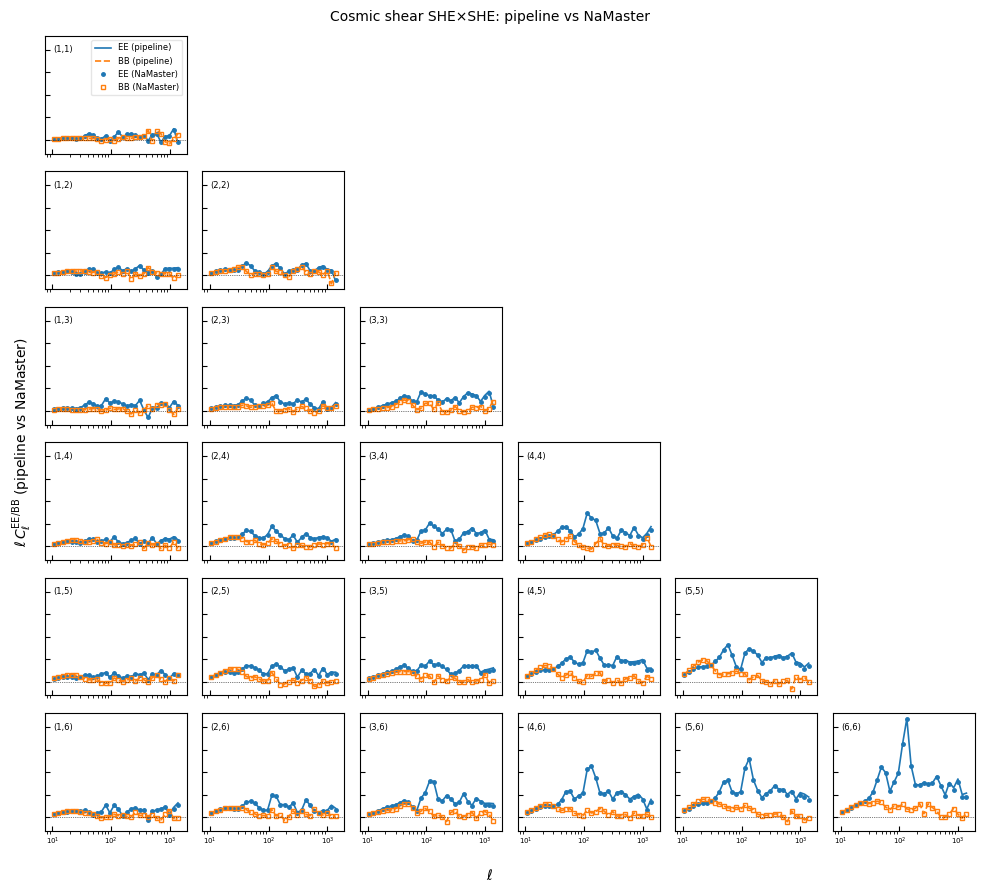

In [23]:
fig, ax = plt.subplots(6, 6, figsize=(10, 9), sharex=True, sharey=True)

for i in range(1, 7):
    for j in range(1, i):
        ax[j - 1, i - 1].axis("off")
    for j in range(i, 7):
        v_pipe = cls_pipe["SHE", "SHE", i, j]
        ell_b = np.asarray(v_pipe.ell)
        ee_pipe = np.asarray(v_pipe[0, 0])
        bb_pipe = np.asarray(v_pipe[1, 1])
        ee_nmt, bb_nmt = namaster_cl[i, j]

        ax[j - 1, i - 1].plot(ell_b, ell_b * ee_pipe, color="C0", lw=1.2, label="EE (pipeline)" if (i == 1 and j == 1) else None)
        ax[j - 1, i - 1].plot(ell_b, ell_b * bb_pipe, color="C1", lw=1.2, ls="--", label="BB (pipeline)" if (i == 1 and j == 1) else None)
        ax[j - 1, i - 1].plot(ell_b, ell_b * ee_nmt, "o", color="C0", ms=2.5, label="EE (NaMaster)" if (i == 1 and j == 1) else None)
        ax[j - 1, i - 1].plot(ell_b, ell_b * bb_nmt, "s", color="C1", ms=2.5, markerfacecolor="none", label="BB (NaMaster)" if (i == 1 and j == 1) else None)

        ax[j - 1, i - 1].axhline(0, color="k", lw=0.5, ls=":")
        ax[j - 1, i - 1].text(0.06, 0.92, f"({i},{j})", transform=ax[j - 1, i - 1].transAxes, fontsize=6, va="top")
        ax[j - 1, i - 1].tick_params(labelsize=5, direction="in")

ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(ell_b[0] * 0.7, ell_b[-1] * 1.4)
ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(numticks=99, subs=np.arange(0.1, 1.0, 0.1))

plt.setp(ax.flat, yticklabels=[])

fig.supxlabel(r"$\ell$", fontsize=10)
fig.supylabel(r"$\ell\,C_\ell^{\rm EE/BB}$ (pipeline vs NaMaster)", fontsize=10)
ax[0, 0].legend(fontsize=6, loc="upper right", framealpha=0.5)
fig.suptitle("Cosmic shear SHE\u00d7SHE: pipeline vs NaMaster", fontsize=10)

plt.tight_layout()
plt.show()